In [1]:
# analysis_museums.py

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [2]:

# ---------------- CONFIG ----------------

DATA_PATH = "/Users/dashailina/Desktop/code/output_clean_1006 copy.csv"  

LANG_COLS = [
    "lang_nl", "lang_en", "lang_de", "lang_fr", "lang_es", "lang_it",
    "lang_pap", "lang_ru", "lang_ja", "lang_zh", "lang_uk", "lang_ar",
    "lang_pt", "lang_ko", "lang_he"
]

# languages representing (post)migrant communities (you can tweak this)
MIGRANT_LANG_COLS = ["lang_ar", "lang_ru", "lang_uk", "lang_zh", "lang_pap"]


In [3]:


# ---------------- STEP 1: LOAD & FEATURE ENGINEERING ----------------

def parse_target_age(text):
    """
    Parse target_age strings (e.g. '4-17 years', '16+ jaar', '0-5 jaar; 13+ jaar')
    and return (min_age, max_age).
    If multiple segments, return the min of mins and max of maxes.
    If nothing parsable, return (None, None).
    """
    if not isinstance(text, str) or not text.strip():
        return (None, None)

    text = text.lower()
    segments = [s.strip() for s in text.split(";") if s.strip()]

    mins = []
    maxs = []

    for seg in segments:
        # ranges: 4-17, 6–12
        m = re.search(r"(\d{1,2})\s*[-–]\s*(\d{1,2})", seg)
        if m:
            lo, hi = int(m.group(1)), int(m.group(2))
            mins.append(lo)
            maxs.append(hi)
            continue

        # '10+ jaar', '12+ years'
        m2 = re.search(r"(\d{1,2})\s*\+\s*(jaar|years)?", seg)
        if m2:
            lo = int(m2.group(1))
            mins.append(lo)
            # assume no explicit upper bound → set to e.g. 99
            maxs.append(99)
            continue

    if not mins or not maxs:
        return (None, None)

    return (min(mins), max(maxs))


def engineer_activity_features(df):
    df = df.copy()

    # --- age-based youth flag ---
    age_bounds = df["target_age"].apply(parse_target_age)
    df["age_min"] = age_bounds.apply(lambda x: x[0])
    df["age_max"] = age_bounds.apply(lambda x: x[1])

    # define youth as max_age <= 18 or if only lower bound and <= 18
    df["is_youth_activity"] = np.where(
        (df["age_max"].notna() & (df["age_max"] <= 18)) |
        (df["age_max"].isna() & df["age_min"].notna() & (df["age_min"] <= 18)),
        1, 0
    )

    # --- activity-type flags from title + URL ---
    def mk_text(row):
        return f"{row.get('activity_title','')} {row.get('activity_url','')}".lower()

    text_all = df.apply(mk_text, axis=1)

    df["is_school_program"] = text_all.str.contains(
        r"onderwijs|school|basisonderwijs|voortgezet onderwijs|edu/|education", regex=True
    ).astype(int)

    df["is_family_activity"] = text_all.str.contains(
        r"family|familie|kids|kinderen|gezin|gezinnen", regex=True
    ).astype(int)

    # --- language features ---
    df["n_languages"] = df[LANG_COLS].sum(axis=1)
    df["has_migrant_language"] = (df[MIGRANT_LANG_COLS].sum(axis=1) > 0).astype(int)

    # simple categorisation
    df["lang_profile"] = "no_language_flag"
    df.loc[(df["lang_nl"]) & (~df["lang_en"]) & (df["n_languages"] == 1), "lang_profile"] = "nl_only"
    df.loc[(df["lang_en"]) & (~df["lang_nl"]) & (df["n_languages"] == 1), "lang_profile"] = "en_only"
    df.loc[df["n_languages"] > 1, "lang_profile"] = "multi_language"

    # --- digital types from description ---
    df["digital_experience_description"] = df["digital_experience_description"].fillna("")

    df["has_vr_ar"] = df["digital_experience_description"].str.contains(
        r"\bvr\b|virtual reality|augmented reality", case=False
    ).astype(int)

    df["has_audio_guide"] = df["digital_experience_description"].str.contains(
        r"audio guide|audioguide|audiotour", case=False
    ).astype(int)

    df["has_interactive"] = df["digital_experience_description"].str.contains(
        r"interactive|interactief", case=False
    ).astype(int)

    df["has_online_tour"] = df["digital_experience_description"].str.contains(
        r"online tour|virtual tour|digitale rondleiding|online rondleiding",
        case=False
    ).astype(int)

    df["has_app"] = df["digital_experience_description"].str.contains(
        r"\bapp\b", case=False
    ).astype(int)

    # ensure boolean columns are 0/1 ints for modeling
    bool_cols = [
        "has_digital_experience", "special_needs_accessible",
        "is_youth_activity", "is_school_program", "is_family_activity",
        "has_migrant_language",
        "has_vr_ar", "has_audio_guide", "has_interactive", "has_online_tour", "has_app",
    ] + LANG_COLS
    for c in bool_cols:
        df[c] = df[c].astype(int)

    return df


def aggregate_museum_level(df):
    """
    Aggregate activity-level data to museum-level descriptors.
    """
    grp = df.groupby("museum_name")

    museum_df = grp.agg(
        n_activities=("activity_id", "count"),
        prop_digital=("has_digital_experience", "mean"),
        prop_youth=("is_youth_activity", "mean"),
        prop_school=("is_school_program", "mean"),
        avg_n_languages=("n_languages", "mean"),
        prop_migrant_lang=("has_migrant_language", "mean"),
        special_needs_accessible=("special_needs_accessible", "max"),
    ).reset_index()

    return museum_df



In [4]:

# ---------------- STEP 2: DESCRIPTIVE STATS & VISUALS ----------------

def descriptive_stats(df, museum_df):
    print("\n=== BASIC COUNTS (activity level) ===")
    print(f"N activities: {len(df)}")
    print("Share with digital experience:", df["has_digital_experience"].mean())
    print("Share special-needs accessible (museum-level signal):", df["special_needs_accessible"].mean())
    print("Share youth activities:", df["is_youth_activity"].mean())
    print("Share school programs:", df["is_school_program"].mean())
    print("Share with migrant-community language:", df["has_migrant_language"].mean())
    print("Average number of languages per activity:", df["n_languages"].mean())

    print("\n=== LANGUAGE PROFILE (activities) ===")
    print(df["lang_profile"].value_counts(normalize=True))

    print("\n=== MUSEUM-LEVEL STATS ===")
    print("N museums:", len(museum_df))
    print("Mean prop_digital:", museum_df["prop_digital"].mean())
    print("Mean prop_youth:", museum_df["prop_youth"].mean())
    print("Mean prop_migrant_lang:", museum_df["prop_migrant_lang"].mean())
    print("Share of museums with special-needs access:", museum_df["special_needs_accessible"].mean())


def heatmap_languages_by_category(df):
    """
    Heatmap: top museum categories (by activity count) vs languages (proportion).
    """
    if "museum_category" not in df.columns:
        print("No museum_category column found; skipping category heatmap.")
        return

    top_cats = df["museum_category"].value_counts().head(10).index
    tmp = df[df["museum_category"].isin(top_cats)]

    heat_data = tmp.groupby("museum_category")[LANG_COLS].mean().sort_index()

    plt.figure(figsize=(10, 6))
    sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="Blues")
    plt.title("Proportion of activities offering each language\nby museum_category (top 10 categories)")
    #plt.tight_layout()
    plt.show()


def heatmap_digital_types_vs_activity_type(df):
    """
    Heatmap: digital tool types vs youth/school/family vs other.
    """
    def activity_type(row):
        if row["is_school_program"]:
            return "school"
        elif row["is_family_activity"]:
            return "family"
        elif row["is_youth_activity"]:
            return "youth_other"
        else:
            return "other"

    df = df.copy()
    df["activity_type"] = df.apply(activity_type, axis=1)

    digital_cols = ["has_vr_ar", "has_audio_guide", "has_interactive", "has_online_tour", "has_app"]
    labels = {
        "has_vr_ar": "VR/AR",
        "has_audio_guide": "audio guide",
        "has_interactive": "interactive",
        "has_online_tour": "online/virtual tour",
        "has_app": "app",
    }

    heat_data = df.groupby("activity_type")[digital_cols].mean().T
    heat_data.index = [labels[c] for c in heat_data.index]

    plt.figure(figsize=(8, 5))
    sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="Oranges")
    plt.title("Proportion of activities using specific digital tools\nby activity type")
    #plt.tight_layout()
    plt.show()


def scatter_digital_vs_youth(museum_df):
    """
    Scatter: % digital vs % youth activities per museum, colored by accessibility.
    """
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        data=museum_df,
        x="prop_digital",
        y="prop_youth",
        hue="special_needs_accessible",
        size="n_activities",
        sizes=(20, 200),
        alpha=0.7,
    )
    plt.xlabel("Proportion of activities with digital tools")
    plt.ylabel("Proportion of activities targeting youth")
    plt.title("Museums: digital vs youth orientation\n(color = special-needs accessible, size = #activities)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    #plt.tight_layout()
    plt.show()



In [5]:

# ---------------- STEP 3: STATISTICAL TESTS ----------------

def chi_square_tests(df):
    print("\n=== CHI-SQUARE TESTS (activity level) ===")

    def chi2_table(x, y, label):
        ct = pd.crosstab(df[x], df[y])
        print(f"\n{label}")
        print(ct)
        chi2, p, dof, exp = stats.chi2_contingency(ct)
        print(f"chi2={chi2:.3f}, dof={dof}, p={p:.4f}")

    chi2_table("is_youth_activity", "has_digital_experience",
               "Youth activity vs digital experience")
    chi2_table("is_school_program", "has_digital_experience",
               "School program vs digital experience")
    chi2_table("has_migrant_language", "has_digital_experience",
               "Migrant-language vs digital experience")


def logistic_regression(df):
    """
    Logistic regression: has_digital_experience ~ youth/school/family + migrant_lang + accessibility + n_languages.
    """
    print("\n=== LOGISTIC REGRESSION: digital ~ youth + school + family + migrant_lang + accessibility + n_languages ===")

    model_df = df[[
        "has_digital_experience",
        "is_youth_activity",
        "is_school_program",
        "is_family_activity",
        "has_migrant_language",
        "special_needs_accessible",
        "n_languages",
        "museum_name",
    ]].dropna()

    # ensure 0/1 ints
    for col in [
        "has_digital_experience",
        "is_youth_activity",
        "is_school_program",
        "is_family_activity",
        "has_migrant_language",
        "special_needs_accessible",
    ]:
        model_df[col] = model_df[col].astype(int)

    formula = (
        "has_digital_experience ~ "
        "is_youth_activity + is_school_program + is_family_activity + "
        "has_migrant_language + special_needs_accessible + n_languages"
    )

    logit_mod = smf.logit(formula, data=model_df)
    logit_res = logit_mod.fit(disp=False)

    print(logit_res.summary())

    # Optional: cluster-robust SE by museum_name
    try:
        robust_res = logit_res.get_robustcov_results(cov_type="cluster", groups=model_df["museum_name"])
        print("\n=== Cluster-robust SE by museum_name ===")
        print(robust_res.summary())
    except Exception as e:
        print("Cluster-robust SE failed:", e)



In [6]:

# ---------------- STEP 4: OPTIONAL CLUSTERING (MUSEUM PROFILES) ----------------

def cluster_museums(museum_df, k=3):
    """
    Cluster museums into profiles based on digital, youth, languages, accessibility.
    """
    features = ["prop_digital", "prop_youth", "prop_migrant_lang", "avg_n_languages", "special_needs_accessible"]
    X = museum_df[features].fillna(0.0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    museum_df = museum_df.copy()
    museum_df["cluster"] = kmeans.fit_predict(X_scaled)

    print("\n=== MUSEUM CLUSTERS ===")
    print(museum_df.groupby("cluster")[features].mean())

    # simple visualization
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        data=museum_df,
        x="prop_digital",
        y="prop_youth",
        hue="cluster",
        size="avg_n_languages",
        sizes=(20, 200),
        alpha=0.8,
        palette="tab10",
    )
    plt.xlabel("Proportion digital")
    plt.ylabel("Proportion youth")
    plt.title("Museum clusters by digital & youth orientation\n(color = cluster, size = avg #languages)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return museum_df



Loaded data: (455, 27)

=== BASIC COUNTS (activity level) ===
N activities: 455
Share with digital experience: 0.2857142857142857
Share special-needs accessible (museum-level signal): 0.7758241758241758
Share youth activities: 0.4945054945054945
Share school programs: 0.3956043956043956
Share with migrant-community language: 0.006593406593406593
Average number of languages per activity: 1.3274725274725274

=== LANGUAGE PROFILE (activities) ===
lang_profile
nl_only           0.778022
multi_language    0.219780
en_only           0.002198
Name: proportion, dtype: float64

=== MUSEUM-LEVEL STATS ===
N museums: 94
Mean prop_digital: 0.28316775859560317
Mean prop_youth: 0.4319166873572517
Mean prop_migrant_lang: 0.031914893617021274
Share of museums with special-needs access: 0.6808510638297872


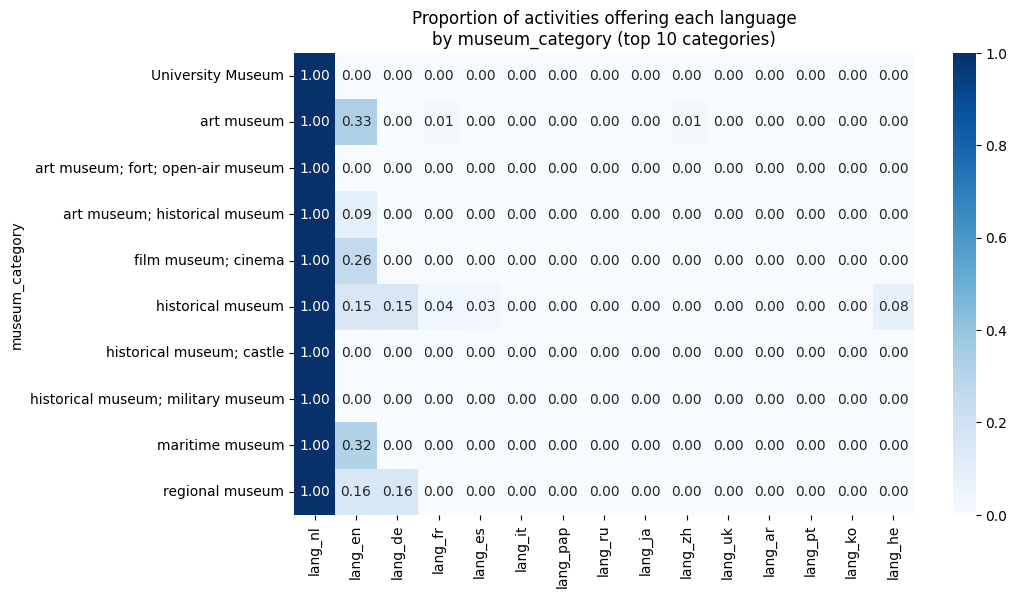

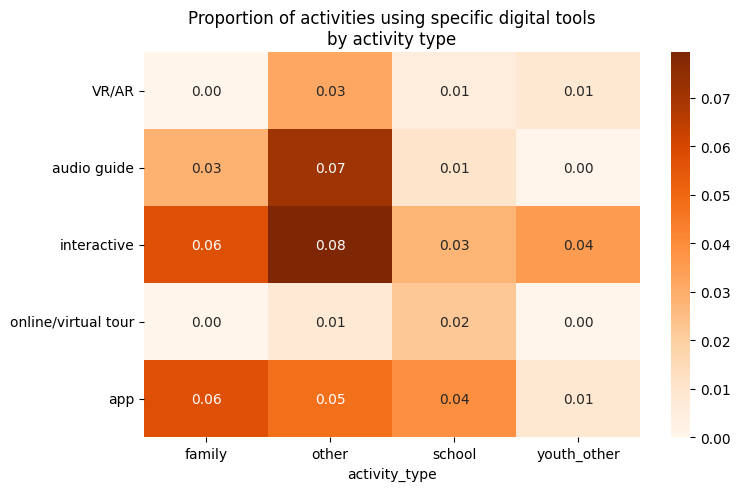

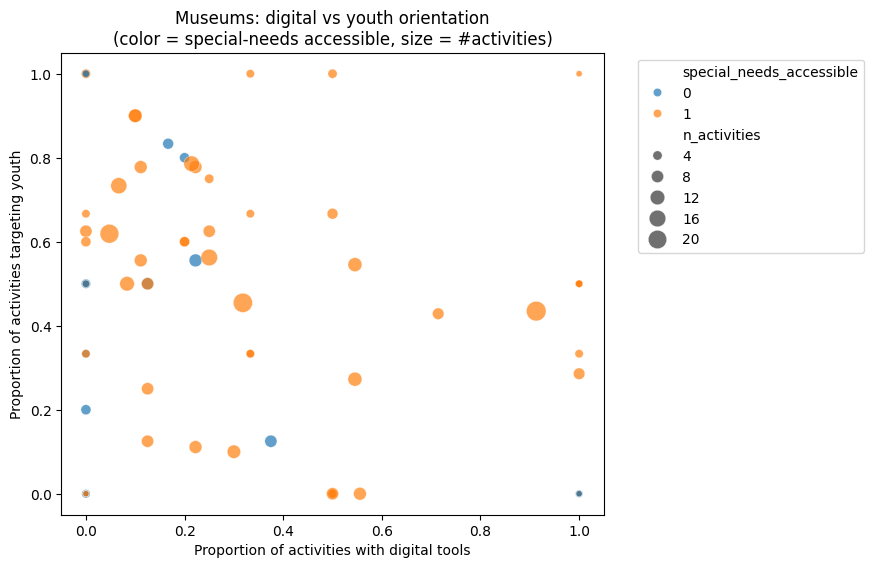


=== CHI-SQUARE TESTS (activity level) ===

Youth activity vs digital experience
has_digital_experience    0   1
is_youth_activity              
0                       147  83
1                       178  47
chi2=12.139, dof=1, p=0.0005

School program vs digital experience
has_digital_experience    0   1
is_school_program              
0                       189  86
1                       136  44
chi2=2.162, dof=1, p=0.1414

Migrant-language vs digital experience
has_digital_experience    0    1
has_migrant_language            
0                       324  128
1                         1    2
chi2=0.679, dof=1, p=0.4098

=== LOGISTIC REGRESSION: digital ~ youth + school + family + migrant_lang + accessibility + n_languages ===
                             Logit Regression Results                             
Dep. Variable:     has_digital_experience   No. Observations:                  455
Model:                              Logit   Df Residuals:                      448
Method:   

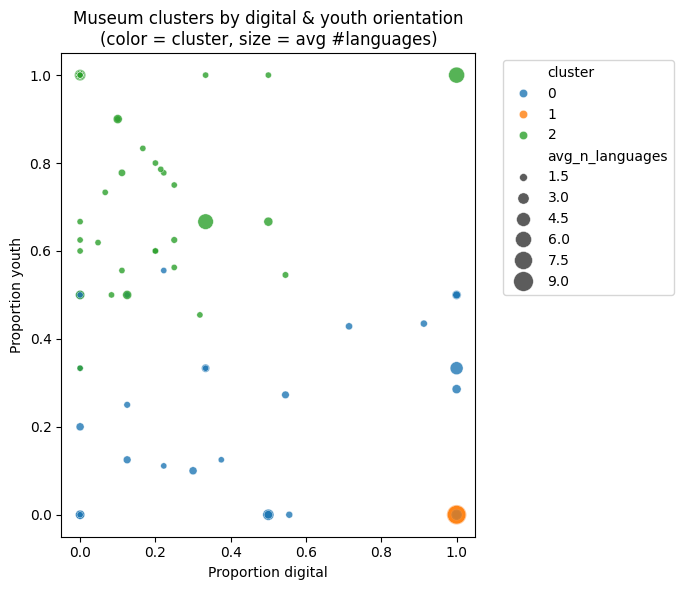

In [7]:

# ---------------- MAIN ----------------

def main():
    # load data
    df = pd.read_csv(DATA_PATH)
    print("Loaded data:", df.shape)

    # engineer activity-level features
    df = engineer_activity_features(df)

    # museum-level aggregation
    museum_df = aggregate_museum_level(df)

    # descriptive stats
    descriptive_stats(df, museum_df)

    # visualizations
    heatmap_languages_by_category(df)
    heatmap_digital_types_vs_activity_type(df)
    scatter_digital_vs_youth(museum_df)

    # statistical tests
    chi_square_tests(df)
    logistic_regression(df)

    # clustering (optional)
    cluster_museums(museum_df, k=3)


if __name__ == "__main__":
    main()